In [59]:
import pandas as pd
import seaborn as sns
#import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from pprint import pprint
#from html_table_parser.parser import HTMLTableParser
from yahooquery import Ticker
import plotly.graph_objects as go
pd.options.display.float_format = '{:,}'.format
import datetime as dt
from datetime import datetime
from sklearn.model_selection import cross_val_score,RepeatedKFold,RepeatedKFold,train_test_split
#import yfinance as yf
import math
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_squared_error
#from fredapi import Fred
from pandas_datareader import data as pdr

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Collection

In [60]:
#inflation
inflation = pdr.get_data_fred('CPIAUCSL').pct_change(periods=12) * 100
inflation = inflation.rename(columns={'CPIAUCSL': 'inflation_rt'})

C:\Users\pbv01\AppData\Local\Temp\ipykernel_16376\3731067956.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation = pdr.get_data_fred('CPIAUCSL').pct_change(periods=12) * 100


In [61]:
#employment - non farming
employment_nonfarm = pdr.get_data_fred('PAYEMS')#.pct_change(periods=12) * 100
employment_nonfarm = employment_nonfarm.rename(columns={'PAYEMS': 'employment_nonfarm'})

In [64]:
#employment - non farming
thirtyr = pdr.get_data_fred('MORTGAGE30US',timeout = 60)#.pct_change(periods=12) * 100
thirtyr = thirtyr.rename(columns={'MORTGAGE30US': 'thirty_yr_rt'})

In [65]:
#employment - non farming
fedfunds = pdr.get_data_fred('FEDFUNDS')#.pct_change(periods=12) * 100
fedfunds = fedfunds.rename(columns={'FEDFUNDS': 'fedfunds_rt'})

In [66]:
#interest - non farming
unemployment = pdr.get_data_fred('UNRATENSA')#.pct_change(periods=12) * 100
unemployment = unemployment.rename(columns={'UNRATENSA': 'unemployment_rt'})

In [67]:
#employment - non farming
delinquencies = pdr.get_data_fred('DRCLACBS')#.pct_change(periods=12) * 100
delinquencies = delinquencies.rename(columns={'DRCLACBS': 'delinquencies_rt'})

In [68]:
thirtyr.sort_values(by='DATE', ascending=False).head()

,thirty_yr_rt
DATE,
2026-06-11,6.520
2026-06-04,6.480
2026-05-28,6.530
2026-05-21,6.510
2026-05-14,6.360


In [69]:
#print(inflation.index.to_list())
#print(employment_nonfarm.index.to_list())
#print(thirtyr.index.to_list())
#print(fedfunds.index.to_list())
#print(unemployment.index.to_list())
#print(delinquencies.index.to_list())

In [70]:
#dim date
start = "2021-07-01"
end = pd.Timestamp.today().normalize()  # or "today"
months = pd.date_range(start=start, end=end, freq="MS")  # month starts

dim_date = pd.DataFrame({"month": months})
dim_date["month_str"] = dim_date["month"].dt.strftime("%Y-%m")

# Cleaning

In [71]:
df = dim_date.merge(inflation, left_on='month',right_index=True,how='left')
df = df.merge(employment_nonfarm, left_on='month',right_index=True,how='left')
df = df.merge(thirtyr, left_on='month',right_index=True,how='left')
df = df.merge(fedfunds, left_on='month',right_index=True,how='left')
df = df.merge(unemployment, left_on='month',right_index=True,how='left')
df = df.merge(delinquencies, left_on='month',right_index=True,how='left')

df = df.iloc[:-1,]

In [72]:
df.head()

,month,month_str,inflation_rt,employment_nonfarm,thirty_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt
0,2021-07-01,2021-07,NaN,146762.000,2.980,0.100,5.700,1.520
1,2021-08-01,2021-08,NaN,147314.000,NaN,0.090,5.300,NaN
2,2021-09-01,2021-09,NaN,147771.000,NaN,0.080,4.600,NaN
3,2021-10-01,2021-10,NaN,148572.000,NaN,0.080,4.300,1.550
4,2021-11-01,2021-11,NaN,149230.000,NaN,0.080,3.900,NaN


In [73]:
print(df.dtypes)
print(df.shape)

df.head()

month                 datetime64[ns]
month_str                     object
inflation_rt                 float64
employment_nonfarm           float64
thirty_yr_rt                 float64
fedfunds_rt                  float64
unemployment_rt              float64
delinquencies_rt             float64
dtype: object
(59, 8)


,month,month_str,inflation_rt,employment_nonfarm,thirty_yr_rt,fedfunds_rt,unemployment_rt,delinquencies_rt
0,2021-07-01,2021-07,NaN,146762.000,2.980,0.100,5.700,1.520
1,2021-08-01,2021-08,NaN,147314.000,NaN,0.090,5.300,NaN
2,2021-09-01,2021-09,NaN,147771.000,NaN,0.080,4.600,NaN
3,2021-10-01,2021-10,NaN,148572.000,NaN,0.080,4.300,1.550
4,2021-11-01,2021-11,NaN,149230.000,NaN,0.080,3.900,NaN


In [74]:
df_long = pd.melt(
    df, 
    id_vars=['month','month_str'], 
    value_vars=['inflation_rt', 'employment_nonfarm', 'thirty_yr_rt', 'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt'],
    var_name='metric', 
    value_name='rate'
)

In [75]:
df_long.head()

,month,month_str,metric,rate
0,2021-07-01,2021-07,inflation_rt,NaN
1,2021-08-01,2021-08,inflation_rt,NaN
2,2021-09-01,2021-09,inflation_rt,NaN
3,2021-10-01,2021-10,inflation_rt,NaN
4,2021-11-01,2021-11,inflation_rt,NaN


# Visualization

In [76]:
df_long.metric.unique()

array(['inflation_rt', 'employment_nonfarm', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt'], dtype=object)

<Axes: xlabel='month', ylabel='rate'>

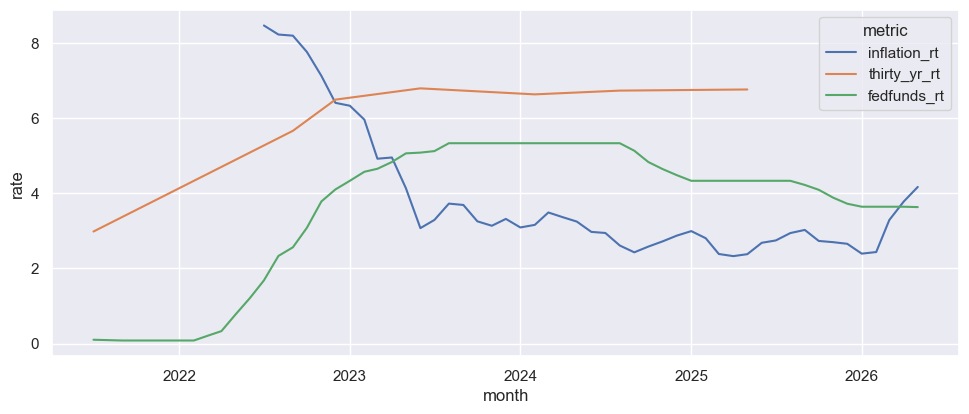

In [77]:
sns.set_theme(rc={'figure.figsize':(11.7,4.5)})

x = df_long.copy()
allowed_metrics = ['inflation_rt','fedfunds_rt','thirty_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

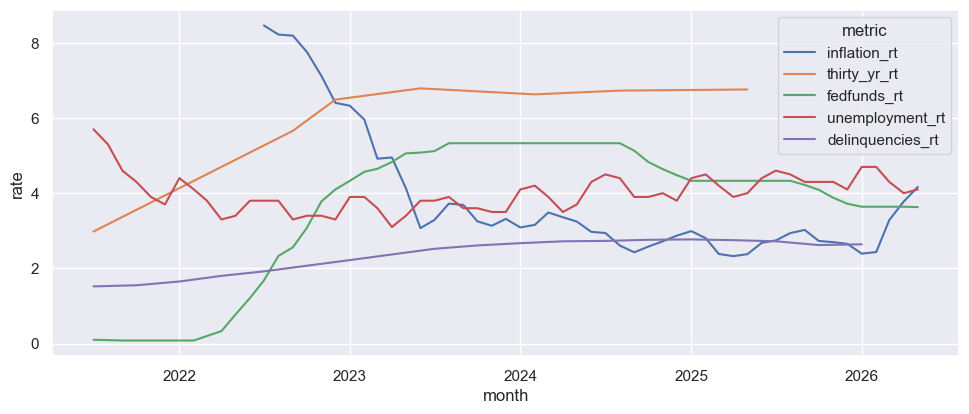

In [80]:
sns.set_theme(rc={'figure.figsize':(11.7,4.5)})

x = df_long.copy()
allowed_metrics = ['inflation_rt', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

In [81]:
print('hello world')

hello world


In [ ]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

In [ ]:
fred.search('PAYEMS').head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
PAYEMS,PAYEMS,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-06-05 08:31:36-05:00,86,"All Employees: Total Nonfarm, commonly known a..."
PAYNSA,PAYNSA,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-06-05 08:30:45-05:00,54,"All Employees: Total Nonfarm, commonly known a..."
